# Session 4 — Feature Scaling, Feature Selection & Outlier Detection
---

## Question 1
**Download a small dataset of IPL cricket player stats (e.g., runs, wickets, matches, strike rate) and apply `StandardScaler` from scikit-learn to scale all numeric features. Save the scaled data to a new CSV file named `ipl_scaled.csv`.**

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Creating IPL Player Stats Dataset
# ============================================================

ipl_data = {
    'player_name': ['Virat Kohli', 'Rohit Sharma', 'MS Dhoni', 'Jasprit Bumrah', 'KL Rahul',
                    'Hardik Pandya', 'Ravindra Jadeja', 'Suryakumar Yadav', 'Rishabh Pant', 'Shubman Gill',
                    'Faf du Plessis', 'David Warner', 'Jos Buttler', 'Rashid Khan', 'Yuzvendra Chahal',
                    'Mohammed Siraj', 'Shreyas Iyer', 'Sanju Samson', 'Ruturaj Gaikwad', 'Yashasvi Jaiswal'],
    'matches':      [237, 243, 250, 120, 109, 117, 210, 95, 109, 72,
                     100, 176, 82, 115, 131, 62, 101, 130, 58, 45],
    'runs':         [7263, 6028, 5082, 145, 4683, 2344, 2692, 2644, 3284, 2048,
                     3403, 6068, 2831, 480, 195, 85, 3127, 3526, 2325, 1658],
    'wickets':      [4, 15, 0, 145, 2, 60, 138, 0, 0, 3,
                     1, 2, 0, 124, 187, 78, 0, 0, 1, 0],
    'strike_rate':  [130.02, 130.50, 135.91, 45.80, 135.38, 153.19, 127.63, 171.89, 148.96, 143.26,
                     131.08, 139.87, 150.40, 120.30, 65.43, 42.15, 126.48, 136.22, 142.81, 158.32],
    'average':      [37.25, 31.05, 39.55, 18.12, 45.46, 28.35, 26.12, 35.12, 34.86, 36.40,
                     34.37, 41.53, 38.79, 14.54, 7.50, 5.31, 32.93, 29.26, 41.60, 39.71],
    'economy_rate': [0.0, 0.0, 0.0, 6.89, 0.0, 7.85, 7.58, 0.0, 0.0, 0.0,
                     0.0, 0.0, 0.0, 6.55, 7.71, 8.92, 0.0, 0.0, 0.0, 0.0]
}

df_ipl = pd.DataFrame(ipl_data)
print("✅ IPL Player Stats Dataset Created")
print(f"Shape: {df_ipl.shape}")
df_ipl

✅ IPL Player Stats Dataset Created
Shape: (20, 7)


,player_name,matches,runs,wickets,strike_rate,average,economy_rate
0,Virat Kohli,237,7263,4,130.02,37.25,0.00
1,Rohit Sharma,243,6028,15,130.50,31.05,0.00
2,MS Dhoni,250,5082,0,135.91,39.55,0.00
3,Jasprit Bumrah,120,145,145,45.80,18.12,6.89
4,KL Rahul,109,4683,2,135.38,45.46,0.00
5,Hardik Pandya,117,2344,60,153.19,28.35,7.85
6,Ravindra Jadeja,210,2692,138,127.63,26.12,7.58
7,Suryakumar Yadav,95,2644,0,171.89,35.12,0.00
8,Rishabh Pant,109,3284,0,148.96,34.86,0.00
9,Shubman Gill,72,2048,3,143.26,36.40,0.00


In [2]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns only
numeric_cols = ['matches', 'runs', 'wickets', 'strike_rate', 'average', 'economy_rate']

print("BEFORE StandardScaler")
print("=" * 60)
print(df_ipl[numeric_cols].describe().round(2))

# Apply StandardScaler
scaler = StandardScaler()
df_ipl_scaled = df_ipl.copy()
df_ipl_scaled[numeric_cols] = scaler.fit_transform(df_ipl[numeric_cols])

print(f"\nAFTER StandardScaler")
print("=" * 60)
print(df_ipl_scaled[numeric_cols].describe().round(2))

print(f"\n✅ After scaling: Mean ≈ 0, Std ≈ 1 for all columns")

BEFORE StandardScaler
       matches     runs  wickets  strike_rate  average  economy_rate
count    20.00    20.00    20.00        20.00    20.00         20.00
mean    128.10  2995.55    38.00       126.78    30.89          2.28
std      62.45  2041.25    61.34        35.01    11.33          3.59
min      45.00    85.00     0.00        42.15     5.31          0.00
25%      91.75  1950.50     0.00       127.34    27.79          0.00
50%     112.00  2761.50     2.00       135.64    34.61          0.00
75%     142.25  3815.25    64.50       144.68    38.98          6.64
max     250.00  7263.00   187.00       171.89    45.46          8.92

AFTER StandardScaler
       matches   runs  wickets  strike_rate  average  economy_rate
count    20.00  20.00    20.00        20.00    20.00         20.00
mean      0.00  -0.00     0.00        -0.00    -0.00          0.00
std       1.03   1.03     1.03         1.03     1.03          1.03
min      -1.37  -1.46    -0.64        -2.48    -2.32         -0.65


In [3]:
# Save scaled data to CSV
df_ipl_scaled.to_csv('ipl_scaled.csv', index=False)
print("✅ Scaled data saved to 'ipl_scaled.csv'")
print(f"\nScaled DataFrame:")
df_ipl_scaled.round(3)

✅ Scaled data saved to 'ipl_scaled.csv'

Scaled DataFrame:


,player_name,matches,runs,wickets,strike_rate,average,economy_rate
0,Virat Kohli,1.789,2.145,-0.569,0.095,0.576,-0.650
1,Rohit Sharma,1.888,1.524,-0.385,0.109,0.014,-0.650
2,MS Dhoni,2.003,1.049,-0.636,0.268,0.784,-0.650
3,Jasprit Bumrah,-0.133,-1.433,1.790,-2.373,-1.156,1.319
4,KL Rahul,-0.314,0.848,-0.602,0.252,1.319,-0.650
5,Hardik Pandya,-0.182,-0.327,0.368,0.774,-0.230,1.593
6,Ravindra Jadeja,1.345,-0.153,1.673,0.025,-0.432,1.516
7,Suryakumar Yadav,-0.544,-0.177,-0.636,1.322,0.383,-0.650
8,Rishabh Pant,-0.314,0.145,-0.636,0.650,0.359,-0.650
9,Shubman Gill,-0.922,-0.476,-0.585,0.483,0.499,-0.650


### What does StandardScaler do?

$$X_{\text{scaled}} = \frac{X - \mu}{\sigma}$$

| Term | Meaning |
|------|---------|
| $X$ | Original value |
| $\mu$ | Mean of the column |
| $\sigma$ | Standard deviation of the column |

- After scaling, every column has **mean ≈ 0** and **std ≈ 1**.
- This is useful when features have **different units/scales** (e.g., runs in thousands vs economy rate in single digits).

---
## Question 2
**Using a dataset of Flipkart product ratings (features: price, rating, number of reviews, discount), apply `MinMaxScaler` so that all features are scaled between 0 and 1. Print the minimum and maximum value for each column before and after scaling.**

*Hint: Use pandas to load the data and scikit-learn's MinMaxScaler for scaling.*

In [4]:
# ============================================================
# Creating Flipkart Product Ratings Dataset
# ============================================================

np.random.seed(42)

flipkart_data = {
    'product_name': [
        'Samsung Galaxy S24', 'iPhone 15', 'OnePlus 12', 'Redmi Note 13', 'Realme GT',
        'HP Laptop 15', 'Dell Inspiron', 'Lenovo IdeaPad', 'Asus VivoBook', 'Acer Aspire',
        'Sony WH-1000XM5', 'boAt Rockerz 450', 'JBL Tune 230NC', 'Samsung Buds2', 'Apple AirPods',
        'Nike Air Max', 'Adidas Ultraboost', 'Puma RS-X', 'Levi\'s Jeans', 'Allen Solly Shirt',
        'Prestige Cooker', 'Bajaj Mixer', 'Philips Trimmer', 'Boat Watch', 'Fire-Boltt Watch'
    ],
    'price':            [74999, 129900, 64999, 17999, 27999,
                         54990, 65490, 47990, 42990, 38990,
                         29990, 1499, 4999, 11999, 14900,
                         8995, 14999, 7499, 3299, 1899,
                         2150, 3499, 1799, 2999, 1599],
    'rating':           [4.5, 4.7, 4.4, 4.1, 4.0,
                         4.2, 4.3, 4.0, 4.1, 3.9,
                         4.6, 3.8, 4.2, 4.3, 4.8,
                         4.1, 4.4, 3.9, 4.0, 3.7,
                         4.3, 4.0, 4.1, 3.6, 3.5],
    'num_reviews':      [25430, 18920, 31200, 89500, 42100,
                         12500, 8900, 15600, 11200, 7800,
                         9800, 156000, 45200, 22300, 14500,
                         6700, 5400, 8200, 34500, 12100,
                         67800, 28900, 42000, 95200, 112000],
    'discount_percent': [12, 8, 15, 25, 20,
                         18, 10, 22, 15, 12,
                         5, 40, 30, 20, 3,
                         35, 28, 45, 50, 40,
                         30, 35, 42, 55, 60]
}

df_flip = pd.DataFrame(flipkart_data)
print("✅ Flipkart Product Ratings Dataset Created")
print(f"Shape: {df_flip.shape}")
df_flip.head(10)

✅ Flipkart Product Ratings Dataset Created
Shape: (25, 5)


,product_name,price,rating,num_reviews,discount_percent
0,Samsung Galaxy S24,74999,4.5,25430,12
1,iPhone 15,129900,4.7,18920,8
2,OnePlus 12,64999,4.4,31200,15
3,Redmi Note 13,17999,4.1,89500,25
4,Realme GT,27999,4.0,42100,20
5,HP Laptop 15,54990,4.2,12500,18
6,Dell Inspiron,65490,4.3,8900,10
7,Lenovo IdeaPad,47990,4.0,15600,22
8,Asus VivoBook,42990,4.1,11200,15
9,Acer Aspire,38990,3.9,7800,12


In [5]:
# Print Min and Max BEFORE scaling
numeric_cols_flip = ['price', 'rating', 'num_reviews', 'discount_percent']

print("BEFORE MinMaxScaler")
print("=" * 55)
before_stats = pd.DataFrame({
    'Min': df_flip[numeric_cols_flip].min(),
    'Max': df_flip[numeric_cols_flip].max()
})
print(before_stats)

BEFORE MinMaxScaler
                     Min       Max
price             1499.0  129900.0
rating               3.5       4.8
num_reviews       5400.0  156000.0
discount_percent     3.0      60.0


In [6]:
from sklearn.preprocessing import MinMaxScaler

# Apply MinMaxScaler
minmax_scaler = MinMaxScaler()
df_flip_scaled = df_flip.copy()
df_flip_scaled[numeric_cols_flip] = minmax_scaler.fit_transform(df_flip[numeric_cols_flip])

# Print Min and Max AFTER scaling
print("AFTER MinMaxScaler")
print("=" * 55)
after_stats = pd.DataFrame({
    'Min': df_flip_scaled[numeric_cols_flip].min(),
    'Max': df_flip_scaled[numeric_cols_flip].max()
})
print(after_stats)
print(f"\n✅ All features are now scaled between 0 and 1")

AFTER MinMaxScaler
                  Min  Max
price             0.0  1.0
rating            0.0  1.0
num_reviews       0.0  1.0
discount_percent  0.0  1.0

✅ All features are now scaled between 0 and 1


In [7]:
# Side-by-side comparison
print("COMPARISON: Before vs After")
print("=" * 65)
comparison = pd.DataFrame({
    'Before_Min': df_flip[numeric_cols_flip].min(),
    'Before_Max': df_flip[numeric_cols_flip].max(),
    'After_Min':  df_flip_scaled[numeric_cols_flip].min().round(2),
    'After_Max':  df_flip_scaled[numeric_cols_flip].max().round(2)
})
print(comparison)

print(f"\nScaled DataFrame (first 10 rows):")
df_flip_scaled.head(10)

COMPARISON: Before vs After
                  Before_Min  Before_Max  After_Min  After_Max
price                 1499.0    129900.0        0.0        1.0
rating                   3.5         4.8        0.0        1.0
num_reviews           5400.0    156000.0        0.0        1.0
discount_percent         3.0        60.0        0.0        1.0

Scaled DataFrame (first 10 rows):


,product_name,price,rating,num_reviews,discount_percent
0,Samsung Galaxy S24,0.572425,0.769231,0.133001,0.157895
1,iPhone 15,1.000000,0.923077,0.089774,0.087719
2,OnePlus 12,0.494544,0.692308,0.171315,0.210526
3,Redmi Note 13,0.128504,0.461538,0.558433,0.385965
4,Realme GT,0.206385,0.384615,0.243692,0.298246
5,HP Laptop 15,0.416593,0.538462,0.047145,0.263158
6,Dell Inspiron,0.498368,0.615385,0.023240,0.122807
7,Lenovo IdeaPad,0.362077,0.384615,0.067729,0.333333
8,Asus VivoBook,0.323136,0.461538,0.038513,0.210526
9,Acer Aspire,0.291984,0.307692,0.015936,0.157895


### What does MinMaxScaler do?

$$X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}$$

- Transforms every value to be **between 0 and 1**.
- The **minimum** value in each column becomes 0, the **maximum** becomes 1.
- Useful when you want all features on the **same scale** without changing the distribution shape.

| Scaler | Output Range | Best For |
|--------|-------------|----------|
| **StandardScaler** | Mean=0, Std=1 | Models sensitive to distribution (SVM, Logistic Regression) |
| **MinMaxScaler** | 0 to 1 | Neural Networks, KNN, distance-based models |

---
## Question 3
**Given a Spotify songs dataset (features: danceability, energy, tempo, popularity), use correlation analysis to select the top 2 features most related to 'popularity'. List the selected features and explain your choice in one line each.**

In [8]:
# ============================================================
# Creating Spotify Songs Dataset
# ============================================================

np.random.seed(10)
n = 100

danceability = np.round(np.clip(np.random.normal(0.65, 0.15, n), 0.1, 1.0), 3)
energy       = np.round(np.clip(np.random.normal(0.60, 0.20, n), 0.05, 1.0), 3)
tempo        = np.round(np.random.uniform(70, 200, n), 1)

# Popularity is influenced more by danceability and energy, less by tempo
popularity = (
    25 * danceability +
    18 * energy +
    0.02 * tempo +
    np.random.normal(30, 8, n)
)
popularity = np.clip(np.round(popularity).astype(int), 10, 100)

df_spotify = pd.DataFrame({
    'danceability': danceability,
    'energy':       energy,
    'tempo':        tempo,
    'popularity':   popularity
})

print("✅ Spotify Songs Dataset Created")
print(f"Shape: {df_spotify.shape}")
df_spotify.head(10)

✅ Spotify Songs Dataset Created
Shape: (100, 4)


,danceability,energy,tempo,popularity
0,0.850,0.623,179.8,74
1,0.757,0.219,140.0,48
2,0.418,0.415,142.7,61
3,0.649,0.694,85.9,62
4,0.743,0.571,119.1,51
5,0.542,0.520,125.7,58
6,0.690,0.541,136.5,67
7,0.666,0.770,185.9,66
8,0.651,0.741,109.0,80
9,0.624,0.443,121.5,58


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation analysis
corr_matrix = df_spotify.corr()

print("CORRELATION MATRIX")
print("=" * 50)
print(corr_matrix.round(4))

# Correlation with 'popularity' (sorted by absolute value)
print(f"\n{'='*50}")
print("Correlation with 'popularity' (sorted):")
print("=" * 50)
pop_corr = corr_matrix['popularity'].drop('popularity').abs().sort_values(ascending=False)
for feat, val in pop_corr.items():
    actual_val = corr_matrix['popularity'][feat]
    print(f"  {feat:<18s} → r = {actual_val:+.4f}  (|r| = {val:.4f})")

CORRELATION MATRIX
              danceability  energy   tempo  popularity
danceability        1.0000  0.0597  0.0331      0.4321
energy              0.0597  1.0000  0.0001      0.3881
tempo               0.0331  0.0001  1.0000      0.0496
popularity          0.4321  0.3881  0.0496      1.0000

Correlation with 'popularity' (sorted):
  danceability       → r = +0.4321  (|r| = 0.4321)
  energy             → r = +0.3881  (|r| = 0.3881)
  tempo              → r = +0.0496  (|r| = 0.0496)


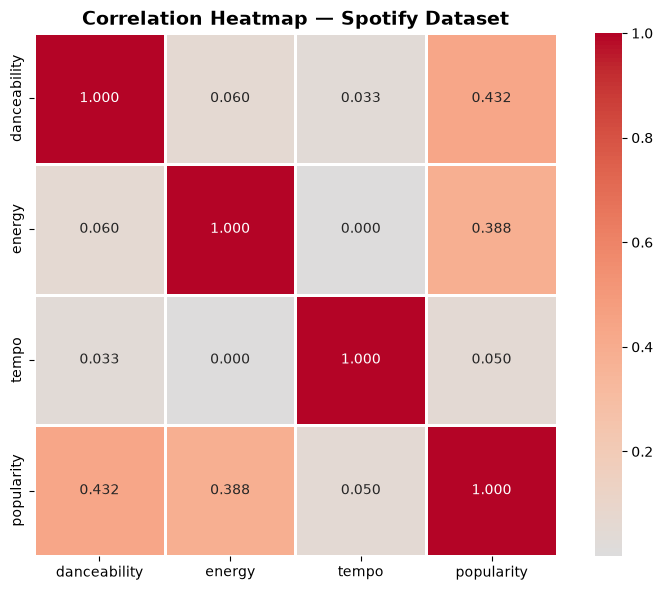

In [10]:
# Heatmap visualization
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap — Spotify Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Select Top 2 features
top_2 = pop_corr.head(2).index.tolist()

print("TOP 2 FEATURES SELECTED")
print("=" * 50)
print(f"\n✅ 1. '{top_2[0]}' (r = {corr_matrix['popularity'][top_2[0]]:+.4f})")
print(f"   → Has the strongest correlation with popularity — higher danceability tends to mean higher popularity.")
print(f"\n✅ 2. '{top_2[1]}' (r = {corr_matrix['popularity'][top_2[1]]:+.4f})")
print(f"   → Has the second strongest correlation — songs with more energy tend to be more popular.")
print(f"\n❌ 'tempo' was NOT selected because its correlation with popularity is very weak (near 0).")

TOP 2 FEATURES SELECTED

✅ 1. 'danceability' (r = +0.4321)
   → Has the strongest correlation with popularity — higher danceability tends to mean higher popularity.

✅ 2. 'energy' (r = +0.3881)
   → Has the second strongest correlation — songs with more energy tend to be more popular.

❌ 'tempo' was NOT selected because its correlation with popularity is very weak (near 0).


---
## Question 4
**Take a Zomato restaurant dataset and use scikit-learn's `RFE` (Recursive Feature Elimination) with a `DecisionTreeRegressor` to select the 3 most important features for predicting 'average cost for two'. List the selected features and the RFE ranking.**

In [12]:
# ============================================================
# Creating Zomato Restaurant Dataset
# ============================================================

np.random.seed(55)
n = 80

zomato_data = {
    'rating':           np.round(np.clip(np.random.normal(3.8, 0.6, n), 1.5, 5.0), 1),
    'num_reviews':      np.random.randint(20, 5000, n),
    'delivery_time':    np.random.randint(15, 75, n),
    'num_cuisines':     np.random.randint(1, 8, n),
    'has_online_order': np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'has_table_booking':np.random.choice([0, 1], n, p=[0.6, 0.4]),
    'location_score':   np.round(np.random.uniform(1, 10, n), 1),
}

# Target: average_cost_for_two (influenced by rating, location, table booking)
avg_cost = (
    120 * zomato_data['rating'] +
    35 * zomato_data['location_score'] +
    200 * zomato_data['has_table_booking'] +
    15 * zomato_data['num_cuisines'] +
    0.02 * zomato_data['num_reviews'] +
    np.random.normal(100, 80, n)
)
zomato_data['avg_cost_for_two'] = np.clip(np.round(avg_cost / 50) * 50, 150, 2500).astype(int)

df_zomato = pd.DataFrame(zomato_data)
print("✅ Zomato Restaurant Dataset Created")
print(f"Shape: {df_zomato.shape}")
df_zomato.head(10)

✅ Zomato Restaurant Dataset Created
Shape: (80, 8)


,rating,num_reviews,delivery_time,num_cuisines,has_online_order,has_table_booking,location_score,avg_cost_for_two
0,2.8,2013,15,1,1,1,3.7,950
1,3.7,3321,66,6,0,0,2.8,650
2,2.7,2104,70,4,1,0,6.4,850
3,4.0,2370,71,6,1,1,9.7,1350
4,4.0,3829,33,6,1,0,3.7,900
5,3.6,2961,50,2,1,0,4.5,800
6,3.8,4671,71,4,0,0,1.9,700
7,4.0,4139,20,3,0,1,1.6,950
8,4.3,2312,41,6,1,0,6.9,1050
9,3.6,2142,68,5,0,0,9.3,1050


In [13]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeRegressor

# Define features (X) and target (y)
feature_cols = ['rating', 'num_reviews', 'delivery_time', 'num_cuisines',
                'has_online_order', 'has_table_booking', 'location_score']
X_zomato = df_zomato[feature_cols]
y_zomato = df_zomato['avg_cost_for_two']

# Apply RFE with DecisionTreeRegressor to select top 3 features
model_dt = DecisionTreeRegressor(random_state=42)
rfe = RFE(estimator=model_dt, n_features_to_select=3)
rfe.fit(X_zomato, y_zomato)

# Results
print("RFE RESULTS — Top 3 Features for 'avg_cost_for_two'")
print("=" * 60)

rfe_results = pd.DataFrame({
    'Feature':  feature_cols,
    'Selected': rfe.support_,
    'Ranking':  rfe.ranking_
}).sort_values('Ranking')

print(rfe_results.to_string(index=False))

selected = rfe_results[rfe_results['Selected'] == True]['Feature'].tolist()
print(f"\n✅ Selected Features (Rank 1): {selected}")
print(f"\nThese 3 features are the most important for predicting average cost for two.")

RFE RESULTS — Top 3 Features for 'avg_cost_for_two'
          Feature  Selected  Ranking
           rating      True        1
has_table_booking      True        1
   location_score      True        1
     num_cuisines     False        2
      num_reviews     False        3
    delivery_time     False        4
 has_online_order     False        5

✅ Selected Features (Rank 1): ['rating', 'has_table_booking', 'location_score']

These 3 features are the most important for predicting average cost for two.


### How RFE Works

1. **Train** the model (DecisionTreeRegressor) using all features.
2. **Rank** features by importance.
3. **Remove** the least important feature.
4. **Repeat** until only the desired number of features remain (3 in our case).

- **Ranking = 1** → Selected (most important)
- **Ranking > 1** → Eliminated (higher rank = eliminated earlier = less important)

---
## Question 5
**Given a BookMyShow movie ratings dataset, detect outliers in the 'user ratings' column using the IQR method. Remove the outliers and display how many rows were dropped.**

*Hint: Calculate Q1, Q3, and IQR; filter out rows outside [Q1 - 1.5×IQR, Q3 + 1.5×IQR].*

In [14]:
# ============================================================
# Creating BookMyShow Movie Ratings Dataset (with outliers)
# ============================================================

np.random.seed(99)

movie_names = [
    'Jawan', 'Pathaan', 'Gadar 2', 'Animal', 'Dunki',
    'Rocky Aur Rani', 'OMG 2', 'The Kerala Story', '12th Fail', 'Sam Bahadur',
    'Tiger 3', 'Oppenheimer', 'Barbie', 'Spider-Verse', 'TMKOC Movie',
    'Fighter', 'Crew', 'Shaitaan', 'Teri Baaton Mein', 'Bade Miyan',
    'Kalki 2898 AD', 'Stree 2', 'Pushpa 2', 'Singham Again', 'Bhool Bhulaiyaa 3',
    'Kantara', 'RRR', 'KGF 2', 'Brahmastra', 'Drishyam 2',
    'Laal Singh Chaddha', 'Shamshera', 'Samrat Prithviraj', 'Liger', 'Adipurush',
    'Radhe', 'Bell Bottom', 'Satyameva Jayate 2', 'Antim', 'Heropanti 2'
]

# Normal ratings between 4–9, plus some OUTLIERS
normal_ratings = np.round(np.clip(np.random.normal(7.0, 1.2, 35), 4.0, 9.5), 1)
outlier_ratings = np.array([0.5, 1.0, 0.8, 10.0, 9.9])  # 5 intentional outliers
all_ratings = np.concatenate([normal_ratings, outlier_ratings])

df_bms = pd.DataFrame({
    'movie_name':  movie_names,
    'user_rating': all_ratings,
    'num_votes':   np.random.randint(500, 100000, 40),
    'genre':       np.random.choice(['Action', 'Drama', 'Comedy', 'Thriller', 'Romance'], 40)
})

print("✅ BookMyShow Movie Ratings Dataset Created")
print(f"Shape: {df_bms.shape}")
df_bms

✅ BookMyShow Movie Ratings Dataset Created
Shape: (40, 4)


,movie_name,user_rating,num_votes,genre
0,Jawan,6.8,33649,Comedy
1,Pathaan,9.5,14820,Thriller
2,Gadar 2,7.3,51126,Romance
3,Animal,8.6,99119,Action
4,Dunki,6.8,91102,Action
5,Rocky Aur Rani,6.9,34375,Thriller
6,OMG 2,7.9,97414,Action
7,The Kerala Story,8.0,78384,Drama
8,12th Fail,6.9,4700,Comedy
9,Sam Bahadur,4.2,62574,Action


In [15]:
# ============================================================
# Detect Outliers using IQR Method
# ============================================================

Q1 = df_bms['user_rating'].quantile(0.25)
Q3 = df_bms['user_rating'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR OUTLIER DETECTION")
print("=" * 45)
print(f"Q1 (25th percentile) : {Q1}")
print(f"Q3 (75th percentile) : {Q3}")
print(f"IQR (Q3 - Q1)        : {IQR}")
print(f"Lower Bound (Q1-1.5×IQR) : {lower_bound}")
print(f"Upper Bound (Q3+1.5×IQR) : {upper_bound}")
print(f"\nValid range: [{lower_bound}, {upper_bound}]")

IQR OUTLIER DETECTION
Q1 (25th percentile) : 6.375
Q3 (75th percentile) : 7.725
IQR (Q3 - Q1)        : 1.3499999999999996
Lower Bound (Q1-1.5×IQR) : 4.3500000000000005
Upper Bound (Q3+1.5×IQR) : 9.75

Valid range: [4.3500000000000005, 9.75]


In [16]:
# Identify outliers
outliers = df_bms[(df_bms['user_rating'] < lower_bound) | (df_bms['user_rating'] > upper_bound)]

print(f"\nOUTLIERS DETECTED: {len(outliers)} rows")
print("=" * 55)
print(outliers[['movie_name', 'user_rating']].to_string(index=True))


OUTLIERS DETECTED: 6 rows
            movie_name  user_rating
9          Sam Bahadur          4.2
35               Radhe          0.5
36         Bell Bottom          1.0
37  Satyameva Jayate 2          0.8
38               Antim         10.0
39         Heropanti 2          9.9


In [17]:
# Remove outliers
df_bms_clean = df_bms[(df_bms['user_rating'] >= lower_bound) & (df_bms['user_rating'] <= upper_bound)]

rows_dropped = len(df_bms) - len(df_bms_clean)

print("AFTER REMOVING OUTLIERS")
print("=" * 45)
print(f"Rows before : {len(df_bms)}")
print(f"Rows after  : {len(df_bms_clean)}")
print(f"Rows dropped: {rows_dropped} ❌")
print(f"\nRating range after cleanup: [{df_bms_clean['user_rating'].min()}, {df_bms_clean['user_rating'].max()}]")

AFTER REMOVING OUTLIERS
Rows before : 40
Rows after  : 34
Rows dropped: 6 ❌

Rating range after cleanup: [5.3, 9.5]


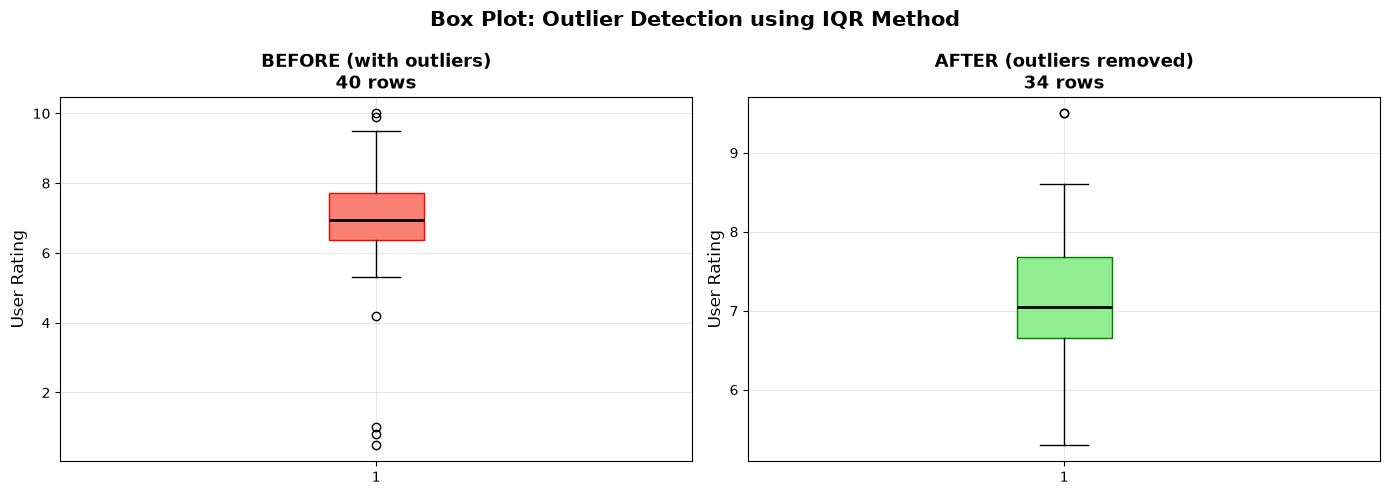

In [18]:
# Visualization: Before vs After
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_bms['user_rating'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='salmon', color='red'),
                medianprops=dict(color='black', linewidth=2))
axes[0].set_title(f'BEFORE (with outliers)\n{len(df_bms)} rows', fontsize=13, fontweight='bold')
axes[0].set_ylabel('User Rating', fontsize=12)
axes[0].grid(alpha=0.3)

axes[1].boxplot(df_bms_clean['user_rating'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', color='green'),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title(f'AFTER (outliers removed)\n{len(df_bms_clean)} rows', fontsize=13, fontweight='bold')
axes[1].set_ylabel('User Rating', fontsize=12)
axes[1].grid(alpha=0.3)

plt.suptitle('Box Plot: Outlier Detection using IQR Method', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### How the IQR Method Works

```
  ◄── Outliers ──►  ◄────── Normal Range ──────►  ◄── Outliers ──►
  ─────────────────┬───────┬───────────┬───────┬─────────────────
                   │       │           │       │
             Q1-1.5×IQR   Q1    Median   Q3   Q3+1.5×IQR
```

| Step | Formula | Value |
|------|---------|-------|
| Q1 | 25th percentile | Lower quartile |
| Q3 | 75th percentile | Upper quartile |
| IQR | Q3 - Q1 | Interquartile range |
| Lower Bound | Q1 - 1.5 × IQR | Any value below this is an outlier |
| Upper Bound | Q3 + 1.5 × IQR | Any value above this is an outlier |